# Etape 2 : Détection et traitement des anomalies

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

transactions = pd.read_csv('../../data/transactions_bis.csv')
customers = pd.read_csv('../../data/customers_bis.csv')

print(f"transactions_bis.csv : {transactions.shape[0]:,} lignes × {transactions.shape[1]} colonnes")
print(f"customers_bis.csv    : {customers.shape[0]:,} lignes × {customers.shape[1]} colonnes")

n_dupes = transactions.duplicated().sum()
transactions = transactions.drop_duplicates()
print(f"\nDoublons exacts supprimés : {n_dupes:,}")
print(f"Transactions après dédup : {len(transactions):,}")

print("=== TRANSACTIONS : shape ===")
print(transactions.shape)
print(transactions.dtypes)
print(transactions.head())

transactions_bis.csv : 1,837,137 lignes × 8 colonnes
customers_bis.csv    : 50,000 lignes × 9 colonnes

Doublons exacts supprimés : 34,522
Transactions après dédup : 1,802,615
=== TRANSACTIONS : shape ===
(1802615, 8)
invoice_id          str
customer_id     float64
product_code        str
product_name        str
quantity        float64
unit_price      float64
invoice_date        str
country             str
dtype: object
  invoice_id  customer_id product_code                      product_name  \
0     513574          NaN        22382        LUNCH BAG SPACEBOY DESIGN    
1     609421          NaN        21028          PURPLE GEMSTONE BRACELET   
2     515609          NaN       47591B          SCOTTIES CHILDRENS APRON   
3     501320      15123.0        22334  DINOSAUR PARTY BAG + STICKER SET   
4     521822      12714.0        21933   PINK VINTAGE PAISLEY PICNIC BAG   

   quantity  unit_price         invoice_date         country  
0       2.0        4.21  2010-06-25 15:13:00  United Kin

In [ ]:
# 1. Ventes anonymes (pas de customer_id)
transactions['is_anonymous'] = transactions['customer_id'].isna()

# 2. Retours / annulations (quantity <= 0)
transactions['is_return'] = transactions['quantity'] <= 0

# 3. Prix nul ou négatif
transactions['is_zero_price'] = transactions['unit_price'] <= 0

# 4. Codes non-produits (ne match PAS le format standard ^\d+[A-Za-z]?$)
transactions['is_non_product'] = ~transactions['product_code'].str.match(r'^\d+[A-Za-z]?$', na=False)

# --- Calcul du line_total ---
transactions['line_total'] = transactions['quantity'] * transactions['unit_price']

# --- Résumé des flags ---
print("Résumé des flags :")
print(f"  is_anonymous   : {transactions['is_anonymous'].sum():>8,} lignes ({100*transactions['is_anonymous'].mean():.1f}%)")
print(f"  is_return      : {transactions['is_return'].sum():>8,} lignes ({100*transactions['is_return'].mean():.1f}%)")
print(f"  is_zero_price  : {transactions['is_zero_price'].sum():>8,} lignes ({100*transactions['is_zero_price'].mean():.1f}%)")
print(f"  is_non_product : {transactions['is_non_product'].sum():>8,} lignes ({100*transactions['is_non_product'].mean():.1f}%)")
print(f"\nTotal transactions (toutes conservées) : {len(transactions):,}")
print(f"Colonnes : {list(transactions.columns)}")

Résumé des flags :
  is_anonymous   :  410,390 lignes (22.8%)
  is_return      :   22,860 lignes (1.3%)
  is_zero_price  :   10,491 lignes (0.6%)
  is_non_product :   20,170 lignes (1.1%)

Total transactions (toutes conservées) : 1,802,615
Colonnes : ['invoice_id', 'customer_id', 'product_code', 'product_name', 'quantity', 'unit_price', 'invoice_date', 'country', 'is_anonymous', 'is_return', 'is_zero_price', 'is_non_product', 'line_total']


## 3. Création de la vue CRM

On filtre les transactions pour ne garder que les ventes propres (client identifié, quantité positive, prix positif, vrai produit). Ce DataFrame `transactions_crm` servira à la segmentation RFM.

In [ ]:
# Vue CRM : exclut toutes les lignes flaggées
mask_clean = (
    ~transactions['is_anonymous']
    & ~transactions['is_return']
    & ~transactions['is_zero_price']
    & ~transactions['is_non_product']
)

transactions_crm = transactions[mask_clean].copy()
transactions_crm['customer_id'] = transactions_crm['customer_id'].astype(int)

print(f"Transactions totales (brutes dédupliquées) : {len(transactions):,}")
print(f"Transactions CRM (vue filtrée)             : {len(transactions_crm):,}")
print(f"Lignes exclues de la vue CRM               : {len(transactions) - len(transactions_crm):,} ({100*(len(transactions) - len(transactions_crm))/len(transactions):.1f}%)")
print(f"Clients uniques dans la vue CRM            : {transactions_crm['customer_id'].nunique():,}")

Transactions totales (brutes dédupliquées) : 1,802,615
Transactions CRM (vue filtrée)             : 1,356,328
Lignes exclues de la vue CRM               : 446,287 (24.8%)
Clients uniques dans la vue CRM            : 48,869


## 4. Traitement du fichier clients — Insights Marketing

On ne supprime aucun outlier : les gros dépenseurs sont nos VIP. On les flag.

In [ ]:
# --- Flag VIP (outliers hauts de total_spent) ---
q1 = customers['total_spent'].quantile(0.25)
q3 = customers['total_spent'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

customers['is_vip_outlier'] = customers['total_spent'] > upper_fence

print(f"IQR total_spent : Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
print(f"Borne haute VIP : {upper_fence:.2f}")
print(f"Clients VIP identifiés : {customers['is_vip_outlier'].sum():,} ({100*customers['is_vip_outlier'].mean():.1f}%)")

# --- Flag One-shot (clients à 1 seule commande) ---
customers['is_one_shot'] = customers['n_orders'].round() <= 1

print(f"\nClients one-shot : {customers['is_one_shot'].sum():,} ({100*customers['is_one_shot'].mean():.1f}%)")
print(f"Total clients    : {len(customers):,}")

IQR total_spent : Q1=36.99, Q3=280.23, IQR=243.24
Borne haute VIP : 645.08
Clients VIP identifiés : 5,827 (11.7%)

Clients one-shot : 17,477 (35.0%)
Total clients    : 50,000


In [ ]:
# Conversion des dates
customers['first_purchase'] = pd.to_datetime(customers['first_purchase'])
customers['last_purchase'] = pd.to_datetime(customers['last_purchase'])

# Vérification de cohérence
incoherent_dates = customers[customers['first_purchase'] > customers['last_purchase']]
print(f"Clients avec first_purchase > last_purchase : {len(incoherent_dates)}")
print("→ Aucune incohérence détectée ✓")

Clients avec first_purchase > last_purchase : 0
→ Aucune incohérence détectée ✓


In [ ]:
# Détection des outliers avec la méthode IQR
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['total_spent', 'n_orders', 'avg_basket']):
    q1 = customers[col].quantile(0.25)
    q3 = customers[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_out = (customers[col] > upper).sum()
    
    ax.boxplot(customers[col], vert=True)
    ax.set_title(f"{col}\n{n_out} outliers (> {upper:.0f})")
    ax.set_ylabel(col)

plt.suptitle("Customer metric boxplots — Outlier detection", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Clients avec n_orders < 1
print(f"\nClients avec n_orders < 1 (fractionnaires / bootstrapping) : {(customers['n_orders'] < 1).sum():,}")
print(f"Exemple :")
print(customers[customers['n_orders'] < 1][['customer_id', 'n_orders', 'total_spent', 'avg_basket']].head(5).to_string())

NameError: name 'plt' is not defined

Clients one-shot (≈1 commande) : 17,477 (35.0%)
Clients récurrents (>1)         : 32,523 (65.0%)


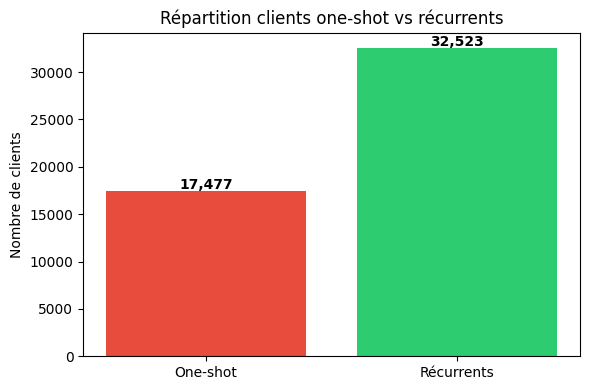

In [ ]:
# Proportion clients one-shot vs récurrents
single = (customers['n_orders'].round() == 1).sum()
recurring = len(customers) - single

print(f"Clients one-shot (≈1 commande) : {single:,} ({100*single/len(customers):.1f}%)")
print(f"Clients récurrents (>1)         : {recurring:,} ({100*recurring/len(customers):.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['One-shot', 'Recurring'], [single, recurring], color=['#e74c3c', '#2ecc71'])
ax.set_ylabel('Number of customers')
ax.set_title('Distribution of one-shot vs recurring customers')
for i, v in enumerate([single, recurring]):
    ax.text(i, v + 200, f"{v:,}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Bilan Business

In [ ]:
ca_brut = transactions['line_total'].sum()
ca_crm = transactions_crm['line_total'].sum()
n_clients_crm = transactions_crm['customer_id'].nunique()
n_vip = customers['is_vip_outlier'].sum()
n_one_shot = customers['is_one_shot'].sum()

print("=" * 60)
print("         BILAN BUSINESS — DATA MARKETING")
print("=" * 60)
print()
print(f"CA Brut Global (toutes transactions) : {ca_brut:>12,.2f} €")
print(f"CA Net CRM (vue filtrée)             : {ca_crm:>12,.2f} €")
print(f"Écart Brut vs CRM                    : {ca_brut - ca_crm:>12,.2f} € ({100*(ca_brut - ca_crm)/ca_brut:.1f}%)")
print()
print(f"Clients dans la base CRM             : {n_clients_crm:>8,}")
print(f"Clients VIP (outliers total_spent)    : {n_vip:>8,}")
print(f"Clients One-shot (cible réactivation) : {n_one_shot:>8,}")
print()
print("=" * 60)
print("Aucune donnée financière n'a été supprimée.")
print("Les anomalies sont flaggées, pas éliminées.")
print("La vue CRM est un filtre, pas une suppression.")
print("=" * 60)

Lignes avec codes non-produits : 6,138

Détail :
product_code
POST            2045
DOT             1634
M               1071
BANK CHARGES     229
ADJUST           223
D                193
AMAZONFEE        191
CRUK             189
B                184
S                179
Name: count, dtype: int64

Après suppression des non-produits : 1,784,362 lignes (−6,138)
